In [37]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import requests
from io import BytesIO
from zipfile import ZipFile, BadZipFile

import numpy as np
import pandas as pd
import pandas_datareader.data as web
from sklearn.datasets import fetch_openml

pd.set_option('display.expand_frame_repr', False)

In [38]:
DATA_STORE = Path('assets.h5')

df = (pd.read_csv('/Users/sheehanmathur/Downloads/wiki_prices.csv',
                 parse_dates=['date'],
                 index_col=['date', 'ticker'],
                 infer_datetime_format=True)
     .sort_index())

print(df.info(show_counts=True))
with pd.HDFStore(DATA_STORE) as store:
    store.put('quandl/wiki/prices', df)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 15389314 entries, (Timestamp('1962-01-02 00:00:00'), 'ARNC') to (Timestamp('2018-03-27 00:00:00'), 'ZUMZ')
Data columns (total 12 columns):
 #   Column       Non-Null Count     Dtype  
---  ------       --------------     -----  
 0   open         15388776 non-null  float64
 1   high         15389259 non-null  float64
 2   low          15389259 non-null  float64
 3   close        15389313 non-null  float64
 4   volume       15389314 non-null  float64
 5   ex-dividend  15389314 non-null  float64
 6   split_ratio  15389313 non-null  float64
 7   adj_open     15388776 non-null  float64
 8   adj_high     15389259 non-null  float64
 9   adj_low      15389259 non-null  float64
 10  adj_close    15389313 non-null  float64
 11  adj_volume   15389314 non-null  float64
dtypes: float64(12)
memory usage: 1.4+ GB
None


In [39]:
df = web.DataReader(name='SP500', data_source='fred', start=2009).squeeze().to_frame('close')
print(df.info())
with pd.HDFStore(DATA_STORE) as store:
    store.put('sp500/fred', df)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2608 entries, 2016-07-25 to 2026-07-22
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   2512 non-null   float64
dtypes: float64(1)
memory usage: 40.8 KB
None


In [40]:
import pandas as pd
import requests
from io import StringIO

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    "User-Agent": "Mozilla/5.0"
}

html = requests.get(url, headers=headers).text

tables = pd.read_html(StringIO(html))
df = tables[0]
df.head()


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [41]:
idx = pd.IndexSlice
with pd.HDFStore(DATA_STORE) as store:
    prices = (store['quandl/wiki/prices']
                    .loc[idx['2000':'2018', :], 'adj_close']
                    .unstack('ticker'))
# price stats
prices.info()

# shifting from daily to monthly prices
monthly_prices = prices.resample('M').last()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4706 entries, 2000-01-03 to 2018-03-27
Columns: 3199 entries, A to ZUMZ
dtypes: float64(3199)
memory usage: 114.9 MB


In [42]:
import pandas as pd

DATA_STORE = "../ML4T/assets.h5"

with pd.HDFStore(DATA_STORE) as store:
    print(store.keys())

['/sp500/fred', '/quandl/wiki/prices']


In [43]:
outlier_cutoff = 0.01
data = pd.DataFrame()
lags = [1,2,3,6,9,12]
for lag in lags:
    data[f'return_{lag}m'] = (monthly_prices
                              .pct_change(lag).stack()
                              .pipe(lambda x:x.clip(lower=x.quantile(outlier_cutoff),
                                                    upper=x.quantile(1-outlier_cutoff)))
                                                    .add(1).pow(1/lag).sub(1)
                                )
data = data.swaplevel().dropna()
data.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 521806 entries, ('A', Timestamp('2001-01-31 00:00:00')) to ('ZUMZ', Timestamp('2018-03-31 00:00:00'))
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   return_1m   521806 non-null  float64
 1   return_2m   521806 non-null  float64
 2   return_3m   521806 non-null  float64
 3   return_6m   521806 non-null  float64
 4   return_9m   521806 non-null  float64
 5   return_12m  521806 non-null  float64
dtypes: float64(6)
memory usage: 26.0+ MB


In [44]:
for lag in [2,3,6,9,12]:
    data[f'momentum_{lag}'] = data[f'return_{lag}m'].sub(data.return_1m)
    data[f'momentum_3_12'] = data[f'return_12m'].sub(data.return_3m)

In [45]:
# To use lagged values as input variables or features associated with the current observations, we use the
# .shift() method to move historical returns up to the current period:
for t in range(1,7):
    data[f'target_{t}m'] = data.groupby(level='ticker').return_1m.shift()


In [46]:
# Similarly, to compute returns for various holding periods, we use the normalized period returns computed
# previously and shift them back to align them with the current financial features
for t in [1,2,3,6,12]:
    data[f'target_{t}m'] = (data.groupby(level='ticker')
                            [f'return_{t}m'].shift(-t))



In [47]:
# Computing factor betas
# The five Fama–French factors, namely market risk, size, value, operating profitability, and investment, have been
# shown empirically to explain asset returns. They are commonly used to assess the exposure of a portfolio
# to well-known drivers of risk and returns.
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

factor_data = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2000'
)[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100)
factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

T = 24

def compute_rolling_betas(x):
    y = x['return_1m']
    X = x[factors]

    # Optional but usually recommended: add intercept
    X = sm.add_constant(X)

    window = min(T, x.shape[0] - 1)

    if window < len(X.columns) + 1:
        return pd.DataFrame(index=x.index, columns=X.columns)

    model = RollingOLS(
        endog=y,
        exog=X,
        window=window
    )

    return model.fit().params

betas = (
    factor_data
    .groupby(level='ticker', group_keys=False)
    .apply(compute_rolling_betas)
)

In [48]:
# How to create forward returns
# Similarly, you can create forward returns for the current period, that is, returns that will occur in the
# future, using .shift() with a negative period (assuming your data is sorted in ascending order):
for t in [1,2,3,6,12]:
    data[f'target_{t}m'] = (data.groupby(level='ticker')[f'return_{t}m'].shift(-t))


In [49]:
# We can compute the Bollinger Bands and, the relative strength index
with pd.HDFStore(DATA_STORE) as store:
    data = (store['quandl/wiki/prices']
            .loc[idx['2007':'2010', 'AAPL'], 
                ['adj_open', 'adj_high', 'adj_low', 'adj_close','adj_volume']]
            .unstack('ticker')
            .swaplevel(axis=1)
            .loc[:, 'AAPL']
            .rename(columns=lambda x: x.replace('adj_', '')))


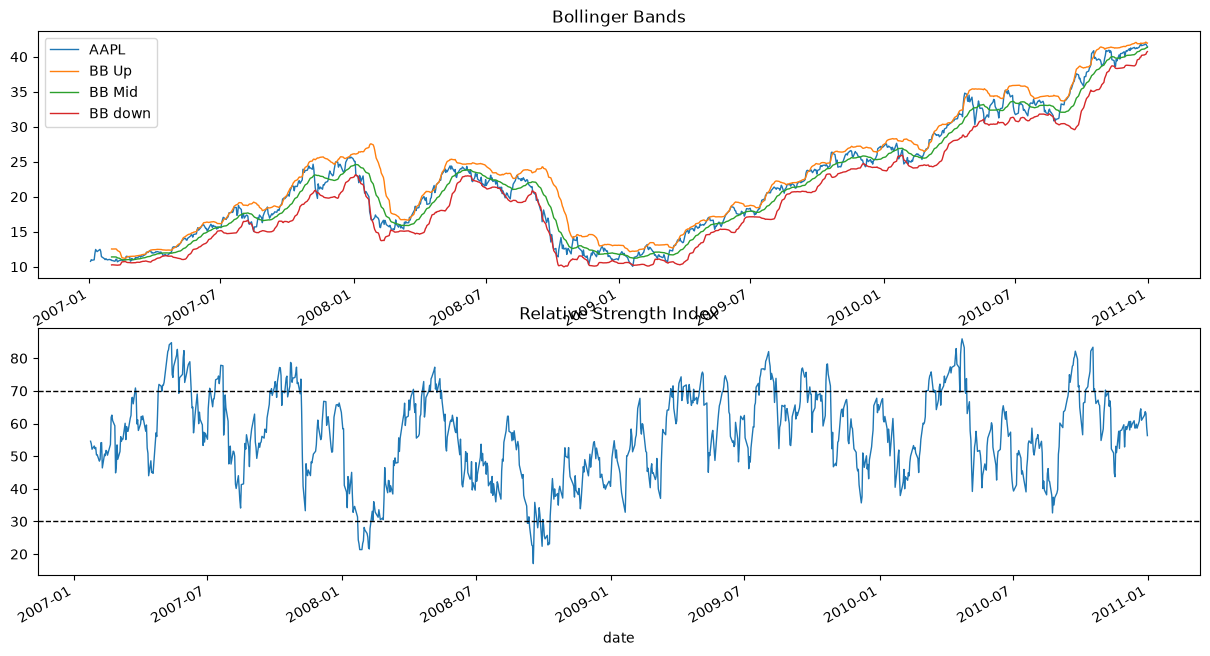

In [50]:
from talib import RSI, BBANDS
import matplotlib.pyplot as plt

up, mid, low = BBANDS(data.close, timeperiod=21, nbdevup=2, nbdevdn=2, matype=0)
rsi = RSI(data.close, timeperiod=14)

data = pd.DataFrame({'AAPL': data.close, 'BB Up': up, 'BB Mid': mid,
'BB down': low, 'RSI': rsi})
fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
data.drop('RSI', axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')

In [55]:
with pd.HDFStore(DATA_STORE) as store:
    sp500 = store['sp500/fred'].loc['2008':'2019','close']

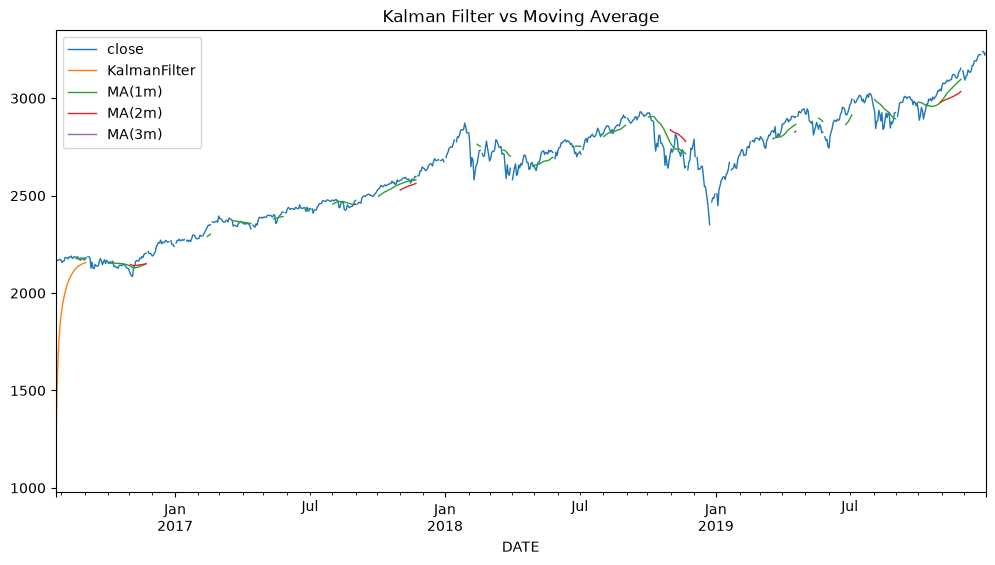

In [ ]:
# We initialize the KalmanFilter with unit covariance matrices and zero means
from pykalman import KalmanFilter
kf = KalmanFilter(transition_matrices=[1], observation_matrices=[1], initial_state_mean=0, 
                  initial_state_covariance=1, observation_covariance=1, transition_covariance=0.01)

# Then, we run the filter method to trigger the forward algorithm, which iteratively estimates the hidden 
# state, that is, the mean of the time series
state_means, _ = kf.filter(sp500)

# Finally, we add moving averages for comparison and plot the result
sp500_smoothed = sp500.to_frame('close')
sp500_smoothed['KalmanFilter'] = state_means
for months in [1,2,3]:
    sp500_smoothed[f'MA({months}m)'] = (sp500.rolling(window = months*21).mean())

ax = sp500_smoothed.plot(title='Kalman Filter vs Moving Average', figsize=(12,6), lw=1, rot=0)

[*********************100%***********************]  1 of 1 completed


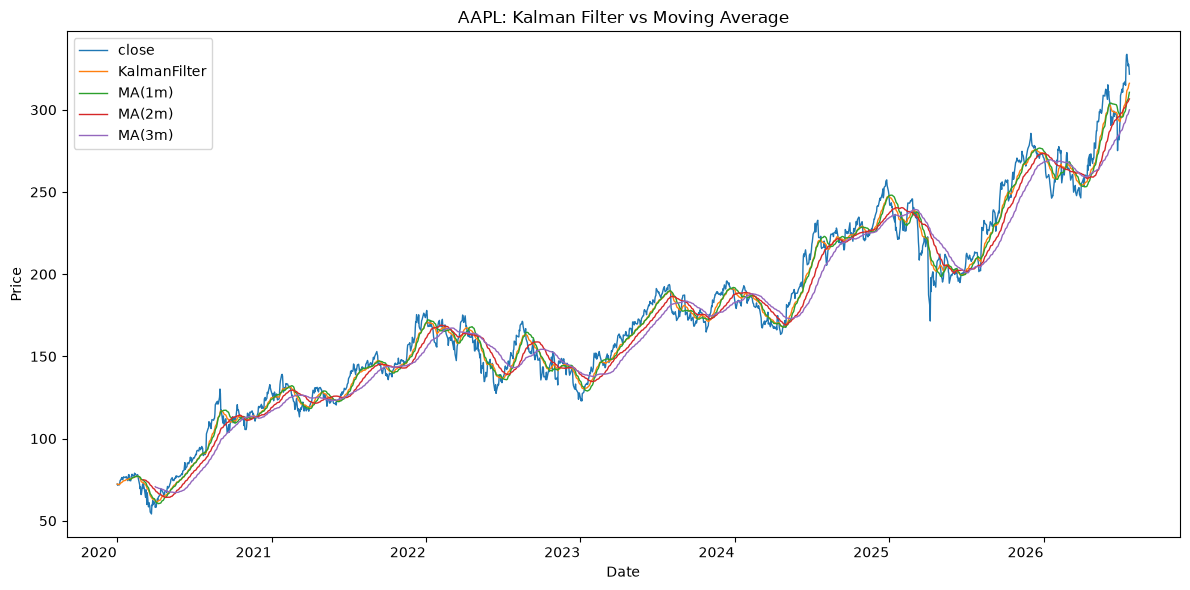

In [ ]:
# Plotting on real-time data

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

ticker = "AAPL"
start = "2020-01-01"
end = None     

df = yf.download(ticker, start=start, end=end, auto_adjust=True)

close = df["Close"].dropna()

if isinstance(close, pd.DataFrame):
    close = close.squeeze()

kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=close.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Run filter
state_means, state_covariances = kf.filter(close.values)

kalman_mean = pd.Series(
    state_means.flatten(),
    index=close.index,
    name="KalmanFilter"
)

smoothed = close.to_frame("close")
smoothed["KalmanFilter"] = kalman_mean

for months in [1, 2, 3]:
    smoothed[f"MA({months}m)"] = close.rolling(window=months * 21).mean()

ax = smoothed.plot(
    title=f"{ticker}: Kalman Filter vs Moving Average",
    figsize=(12, 6),
    lw=1,
    rot=0
)

ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


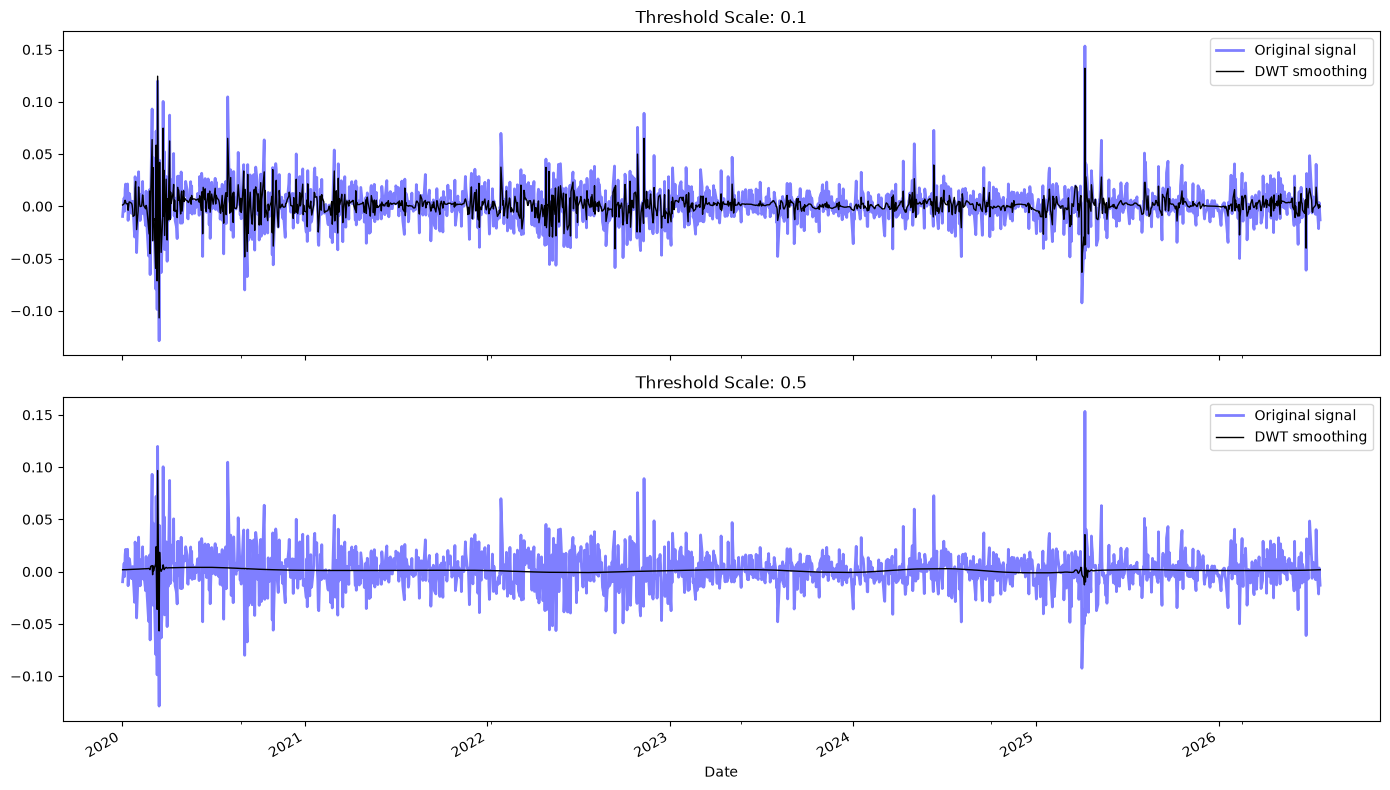

In [66]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import pywt

ticker = "AAPL"
start = "2020-01-01"
end = None

df = yf.download(ticker, start=start, end=end, auto_adjust=True)

# Make sure signal is a Series
signal = df["Close"].pct_change().dropna().squeeze()

wavelet = "db6"

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

for i, scale in enumerate([0.1, 0.5]):
    coefficients = pywt.wavedec(signal, wavelet, mode="per")

    threshold_value = scale * signal.abs().max()

    coefficients[1:] = [
        pywt.threshold(c, value=threshold_value, mode="soft")
        for c in coefficients[1:]
    ]

    reconstructed_signal = pywt.waverec(coefficients, wavelet, mode="per")

    # Important: match original signal length
    reconstructed_signal = reconstructed_signal[:len(signal)]

    signal.plot(
        color="b",
        alpha=0.5,
        label="Original signal",
        lw=2,
        title=f"Threshold Scale: {scale:.1f}",
        ax=axes[i]
    )

    pd.Series(
        reconstructed_signal,
        index=signal.index
    ).plot(
        color="k",
        label="DWT smoothing",
        linewidth=1,
        ax=axes[i]
    )

    axes[i].legend()

plt.tight_layout()
plt.show()